# Welcome to Colab!

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Prediction for 3000: [1]

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



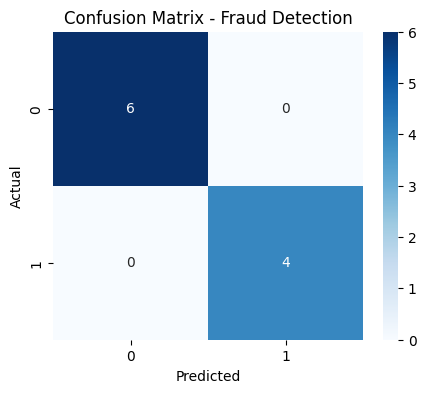

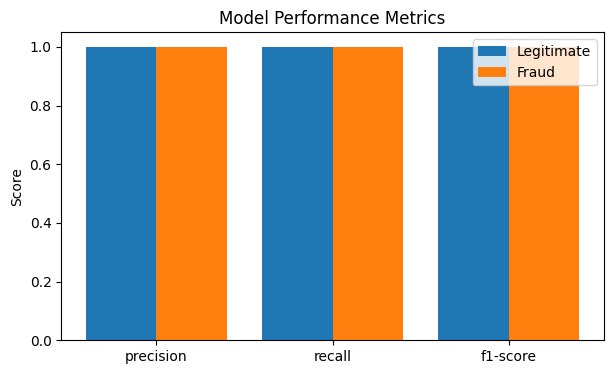


===== FINAL SUMMARY =====
Accuracy: 1.00
Model Type: Logistic Regression
Task: Fraud Detection (Binary Classification)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# =========================
# 1. CREATE / LOAD DATA
# =========================
data = {
    "amount": [100, 200, 500, 50, 10000, 3000, 120, 7000, 80, 4500],
    "label":  [0,   0,   0,   0,   1,     1,    0,   1,    0,   1]
}

df = pd.DataFrame(data)

X = df[["amount"]]
y = df["label"]

# =========================
# 2. TRAIN MODEL
# =========================
model = LogisticRegression()
model.fit(X, y)

# =========================
# 3. PREDICTIONS
# =========================
y_pred = model.predict(X)

# Example prediction
test_value = np.array([[3000]])
print("\nPrediction for 3000:", model.predict(test_value))

# =========================
# 4. EVALUATION METRICS
# =========================
accuracy = accuracy_score(y, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# =========================
# 5. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Fraud Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 6. METRICS VISUALIZATION
# =========================
report = classification_report(y, y_pred, output_dict=True)

metrics = ["precision", "recall", "f1-score"]

fraud_scores = [report["1"][m] for m in metrics]
legit_scores = [report["0"][m] for m in metrics]

x = np.arange(len(metrics))

plt.figure(figsize=(7,4))
plt.bar(x - 0.2, legit_scores, width=0.4, label="Legitimate")
plt.bar(x + 0.2, fraud_scores, width=0.4, label="Fraud")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.legend()
plt.show()

# =========================
# 7. PRINT SUMMARY
# =========================
print("\n===== FINAL SUMMARY =====")
print(f"Accuracy: {accuracy:.2f}")
print("Model Type: Logistic Regression")
print("Task: Fraud Detection (Binary Classification)")